# 🏀 NBA TEAMS.CSV - KAPSAMLI TAKIM BİLGİLERİ ANALİZİ

Bu notebook, **teams.csv** dosyasını wget ile indirir ve çok detaylı takım profil analizleri yapar.

## Dataset İçeriği
- **Takım Bilgileri:** İsimler, kısaltmalar, ID'ler
- **Şehir Bilgileri:** Takımların bulunduğu şehirler
- **Kuruluş Bilgileri:** YEARFOUNDED, tarihsel veriler
- **Takım Özellikleri:** Nickname, abbreviation, arena bilgileri
- **Konferans/Division:** Takım gruplandırmaları

## Analiz Kapsamı
1. Veri indirme ve yükleme (Wget)
2. Temel keşifsel analiz
3. Detaylı eksik veri analizi
4. Takım isim ve kısaltma analizleri
5. Şehir dağılımları (multi-team cities)
6. Kuruluş yılı deep dive
7. Tarihsel takım analizi
8. Nickname pattern analizi
9. Arena bilgileri analizi
10. Konferans/Division dağılımları
11. Coğrafi analiz
12. Takım yaş analizi
13. İsim uzunluğu analizleri
14. İleri düzey içgörüler

## 📦 Kütüphane Kurulumu ve Import

In [1]:
# Gerekli kütüphaneler
import os
import subprocess
import zipfile
import glob
from pathlib import Path
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import datetime

# Görselleştirme ayarları
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
%matplotlib inline

# Pandas ayarları
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.3f}'.format)

print('Kütüphaneler başarıyla yüklendi!')
print(f'Pandas version: {pd.__version__}')
print(f'NumPy version: {np.__version__}')
print(f'Matplotlib version: {plt.matplotlib.__version__}')
print(f'Seaborn version: {sns.__version__}')

Kütüphaneler başarıyla yüklendi!
Pandas version: 2.2.2
NumPy version: 2.0.2
Matplotlib version: 3.10.0
Seaborn version: 0.13.2


## 📥 Dataset İndirme (Wget ile Kaggle)

In [2]:
def download_dataset_direct(download_url, dest_folder, zip_filename):
    """Wget ile dataset indir"""
    if not os.path.exists(dest_folder):
        os.makedirs(dest_folder)

    full_zip_path = os.path.join(dest_folder, zip_filename)

    print(f"\n{'='*70}")
    print(f"Indiriliyor: {zip_filename}")
    print(f"URL: {download_url}")
    print(f"{'='*70}")
    print("Bu islem birkac dakika surebilir...\n")

    try:
        cmd = ["wget", "-O", full_zip_path, download_url]
        subprocess.run(cmd, check=True)
        print(f"\nIndirme basarili: {full_zip_path}")
        return True
    except Exception as e:
        print(f"\nIndirme hatasi: {e}")
        return False

def extract_dataset(dest_folder):
    """Zip dosyasını aç"""
    try:
        zip_files = glob.glob(os.path.join(dest_folder, "*.zip"))
        if not zip_files:
            print(f"Zip bulunamadi: {dest_folder}")
            return False

        for zip_file in zip_files:
            print(f"\nAciliyor: {zip_file}")
            with zipfile.ZipFile(zip_file, 'r') as zip_ref:
                zip_ref.extractall(dest_folder)
            os.remove(zip_file)
            print(f"Zip silindi")

        print(f"\nDataset hazir: {dest_folder}")
        return True
    except Exception as e:
        print(f"Hata: {e}")
        return False

In [3]:
# Dataset klasörü
dataset_folder = "nba_games_dataset"
os.makedirs(dataset_folder, exist_ok=True)

# Dataset bilgileri
dataset_info = {
    "name": "nba-games",
    "download_url": "https://www.kaggle.com/api/v1/datasets/download/nathanlauga/nba-games",
    "folder": dataset_folder,
    "zip_filename": "nba-games.zip"
}

# teams.csv var mı kontrol et
teams_path = os.path.join(dataset_folder, "teams.csv")
if os.path.exists(teams_path):
    print("\n" + "="*70)
    print("Dataset zaten mevcut!")
    print("="*70)
else:
    print("\n" + "="*70)
    print("NBA GAMES DATASET INDIRILIYOR")
    print("="*70)

    success = download_dataset_direct(
        dataset_info["download_url"],
        dataset_info["folder"],
        dataset_info["zip_filename"]
    )

    if success:
        extract_dataset(dataset_info["folder"])
    else:
        print("\n" + "="*70)
        print("MANUEL INDIRME GEREKLI")
        print("="*70)
        print("1. https://www.kaggle.com/datasets/nathanlauga/nba-games")
        print("2. Download butonuna tiklayin")
        print(f"3. Zipi {dataset_folder}/ klasorune koyun")
        print("4. Bu hucreyi tekrar calistirin")


NBA GAMES DATASET INDIRILIYOR

Indiriliyor: nba-games.zip
URL: https://www.kaggle.com/api/v1/datasets/download/nathanlauga/nba-games
Bu islem birkac dakika surebilir...


Indirme basarili: nba_games_dataset/nba-games.zip

Aciliyor: nba_games_dataset/nba-games.zip
Zip silindi

Dataset hazir: nba_games_dataset


In [4]:
# Dataset dosyalarını listele
csv_files = sorted(glob.glob(os.path.join(dataset_folder, "*.csv")))

if csv_files:
    print("\n" + "="*70)
    print("DATASET DOSYALARI")
    print("="*70)

    for csv_file in csv_files:
        filename = os.path.basename(csv_file)
        file_size = os.path.getsize(csv_file) / (1024 * 1024)
        print(f"  {filename:30} - {file_size:8.2f} MB")

    print("="*70)
else:
    print("CSV dosyalari bulunamadi!")


DATASET DOSYALARI
  games.csv                      -     3.92 MB
  games_details.csv              -    88.77 MB
  players.csv                    -     0.25 MB
  ranking.csv                    -    14.73 MB
  teams.csv                      -     0.00 MB


## 📊 TEAMS.CSV - Veri Yükleme ve İlk Bakış

In [5]:
# teams.csv dosyasını yükle
teams_file = os.path.join(dataset_folder, "teams.csv")
df = pd.read_csv(teams_file)

print("="*70)
print("TEAMS.CSV - TEMEL BILGILER")
print("="*70)
print(f"\nToplam Kayit Sayisi: {len(df):,}")
print(f"Sutun Sayisi: {len(df.columns)}")
print(f"Bellek Kullanimi: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

if 'TEAM_ID' in df.columns:
    print(f"\nBenzersiz Takim ID: {df['TEAM_ID'].nunique()}")

if 'NICKNAME' in df.columns:
    print(f"Benzersiz Nickname: {df['NICKNAME'].nunique()}")

if 'CITY' in df.columns:
    print(f"Benzersiz Sehir: {df['CITY'].nunique()}")

if 'YEARFOUNDED' in df.columns:
    print(f"Kurulus Yili Araligi: {df['YEARFOUNDED'].min():.0f} - {df['YEARFOUNDED'].max():.0f}")

print(f"\nVeri Sekli (shape): {df.shape}")
print("="*70)

TEAMS.CSV - TEMEL BILGILER

Toplam Kayit Sayisi: 30
Sutun Sayisi: 14
Bellek Kullanimi: 0.02 MB

Benzersiz Takim ID: 30
Benzersiz Nickname: 30
Benzersiz Sehir: 29
Kurulus Yili Araligi: 1946 - 2002

Veri Sekli (shape): (30, 14)


In [6]:
# Tüm takım listesi
print("\nTUM NBA TAKIMLARI:")
print("="*70)
df.head(50)


TUM NBA TAKIMLARI:


,LEAGUE_ID,TEAM_ID,MIN_YEAR,MAX_YEAR,ABBREVIATION,NICKNAME,YEARFOUNDED,CITY,ARENA,ARENACAPACITY,OWNER,GENERALMANAGER,HEADCOACH,DLEAGUEAFFILIATION
0,0,1610612737,1949,2019,ATL,Hawks,1949,Atlanta,State Farm Arena,18729.000,Tony Ressler,Travis Schlenk,Lloyd Pierce,Erie Bayhawks
1,0,1610612738,1946,2019,BOS,Celtics,1946,Boston,TD Garden,18624.000,Wyc Grousbeck,Danny Ainge,Brad Stevens,Maine Red Claws
2,0,1610612740,2002,2019,NOP,Pelicans,2002,New Orleans,Smoothie King Center,NaN,Tom Benson,Trajan Langdon,Alvin Gentry,No Affiliate
3,0,1610612741,1966,2019,CHI,Bulls,1966,Chicago,United Center,21711.000,Jerry Reinsdorf,Gar Forman,Jim Boylen,Windy City Bulls
4,0,1610612742,1980,2019,DAL,Mavericks,1980,Dallas,American Airlines Center,19200.000,Mark Cuban,Donnie Nelson,Rick Carlisle,Texas Legends
5,0,1610612743,1976,2019,DEN,Nuggets,1976,Denver,Pepsi Center,19099.000,Stan Kroenke,Tim Connelly,Michael Malone,No Affiliate
6,0,1610612745,1967,2019,HOU,Rockets,1967,Houston,Toyota Center,18104.000,Tilman Fertitta,Daryl Morey,Mike D'Antoni,Rio Grande Valley Vipers
7,0,1610612746,1970,2019,LAC,Clippers,1970,Los Angeles,Staples Center,19060.000,Steve Ballmer,Michael Winger,Doc Rivers,Agua Caliente Clippers of Ontario
8,0,1610612747,1948,2019,LAL,Lakers,1948,Los Angeles,Staples Center,19060.000,Jerry Buss Family Trust,Rob Pelinka,Frank Vogel,South Bay Lakers
9,0,1610612748,1988,2019,MIA,Heat,1988,Miami,AmericanAirlines Arena,19600.000,Micky Arison,Pat Riley,Erik Spoelstra,Sioux Falls Skyforce


In [7]:
# Rastgele 10 takım
print("\nRASTGELE 10 TAKIM:")
print("="*70)
df.sample(min(10, len(df)), random_state=42)


RASTGELE 10 TAKIM:


,LEAGUE_ID,TEAM_ID,MIN_YEAR,MAX_YEAR,ABBREVIATION,NICKNAME,YEARFOUNDED,CITY,ARENA,ARENACAPACITY,OWNER,GENERALMANAGER,HEADCOACH,DLEAGUEAFFILIATION
27,0,1610612766,1988,2019,CHA,Hornets,1988,Charlotte,Spectrum Center,19026.000,Michael Jordan,Mitch Kupchak,James Borrego,Greensboro Swarm
15,0,1610612754,1976,2019,IND,Pacers,1976,Indiana,Bankers Life Fieldhouse,18345.000,Herb Simon,Kevin Pritchard,Nate McMillan,Fort Wayne Mad Ants
23,0,1610612762,1974,2019,UTA,Jazz,1974,Utah,Vivint Smart Home Arena,20148.000,Greg Miller,Dennis Lindsey,Quin Snyder,Salt Lake City Stars
17,0,1610612756,1968,2019,PHX,Suns,1968,Phoenix,Talking Stick Resort Arena,NaN,Robert Sarver,James Jones,Monty Williams,Northern Arizona Suns
8,0,1610612747,1948,2019,LAL,Lakers,1948,Los Angeles,Staples Center,19060.000,Jerry Buss Family Trust,Rob Pelinka,Frank Vogel,South Bay Lakers
9,0,1610612748,1988,2019,MIA,Heat,1988,Miami,AmericanAirlines Arena,19600.000,Micky Arison,Pat Riley,Erik Spoelstra,Sioux Falls Skyforce
28,0,1610612739,1970,2019,CLE,Cavaliers,1970,Cleveland,Quicken Loans Arena,20562.000,Dan Gilbert,Koby Altman,John Beilein,Canton Charge
24,0,1610612763,1995,2019,MEM,Grizzlies,1995,Memphis,FedExForum,18119.000,Robert Pera,Zach Kleiman,Taylor Jenkins,Memphis Hustle
12,0,1610612751,1976,2019,BKN,Nets,1976,Brooklyn,Barclays Center,NaN,Joe Tsai,Sean Marks,Kenny Atkinson,Long Island Nets
0,0,1610612737,1949,2019,ATL,Hawks,1949,Atlanta,State Farm Arena,18729.000,Tony Ressler,Travis Schlenk,Lloyd Pierce,Erie Bayhawks


In [8]:
# Sütun tipleri ve bilgileri
print("\n" + "="*70)
print("SUTUN BILGILERI VE VERI TIPLERI")
print("="*70)
df.info()


SUTUN BILGILERI VE VERI TIPLERI
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   LEAGUE_ID           30 non-null     int64  
 1   TEAM_ID             30 non-null     int64  
 2   MIN_YEAR            30 non-null     int64  
 3   MAX_YEAR            30 non-null     int64  
 4   ABBREVIATION        30 non-null     object 
 5   NICKNAME            30 non-null     object 
 6   YEARFOUNDED         30 non-null     int64  
 7   CITY                30 non-null     object 
 8   ARENA               30 non-null     object 
 9   ARENACAPACITY       26 non-null     float64
 10  OWNER               30 non-null     object 
 11  GENERALMANAGER      30 non-null     object 
 12  HEADCOACH           30 non-null     object 
 13  DLEAGUEAFFILIATION  30 non-null     object 
dtypes: float64(1), int64(5), object(8)
memory usage: 3.4+ KB


In [9]:
# Tüm sütun isimleri detaylı
print("\n" + "="*70)
print(f"TUM SUTUNLAR ({len(df.columns)} adet) - DETAYLI")
print("="*70)

for i, col in enumerate(df.columns, 1):
    dtype = df[col].dtype
    unique = df[col].nunique()
    null_count = df[col].isnull().sum()

    # Örnek değer
    sample = df[col].dropna().iloc[0] if len(df[col].dropna()) > 0 else 'N/A'

    print(f"{i:2d}. {col:25} | Type: {str(dtype):10} | Unique: {unique:3} | Null: {null_count:3} | Sample: {str(sample)[:30]}")


TUM SUTUNLAR (14 adet) - DETAYLI
 1. LEAGUE_ID                 | Type: int64      | Unique:   1 | Null:   0 | Sample: 0
 2. TEAM_ID                   | Type: int64      | Unique:  30 | Null:   0 | Sample: 1610612737
 3. MIN_YEAR                  | Type: int64      | Unique:  15 | Null:   0 | Sample: 1949
 4. MAX_YEAR                  | Type: int64      | Unique:   1 | Null:   0 | Sample: 2019
 5. ABBREVIATION              | Type: object     | Unique:  30 | Null:   0 | Sample: ATL
 6. NICKNAME                  | Type: object     | Unique:  30 | Null:   0 | Sample: Hawks
 7. YEARFOUNDED               | Type: int64      | Unique:  15 | Null:   0 | Sample: 1949
 8. CITY                      | Type: object     | Unique:  29 | Null:   0 | Sample: Atlanta
 9. ARENA                     | Type: object     | Unique:  29 | Null:   0 | Sample: State Farm Arena
10. ARENACAPACITY             | Type: float64    | Unique:  24 | Null:   4 | Sample: 18729.0
11. OWNER                     | Type: object 

In [10]:
# İstatistiksel özet
print("\n" + "="*70)
print("ISTATISTIKSEL OZET")
print("="*70)
df.describe(include='all').T


ISTATISTIKSEL OZET


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
LEAGUE_ID,30.000,NaN,NaN,NaN,0.000,0.000,0.000,0.000,0.000,0.000,0.000
TEAM_ID,30.000,NaN,NaN,NaN,1610612751.500,8.803,1610612737.000,1610612744.250,1610612751.500,1610612758.750,1610612766.000
MIN_YEAR,30.000,NaN,NaN,NaN,1969.700,16.698,1946.000,1952.000,1970.000,1979.000,2002.000
MAX_YEAR,30.000,NaN,NaN,NaN,2019.000,0.000,2019.000,2019.000,2019.000,2019.000,2019.000
ABBREVIATION,30,30,ATL,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NICKNAME,30,30,Hawks,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YEARFOUNDED,30.000,NaN,NaN,NaN,1969.700,16.698,1946.000,1952.000,1970.000,1979.000,2002.000
CITY,30,29,Los Angeles,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ARENA,30,29,Staples Center,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ARENACAPACITY,26.000,NaN,NaN,NaN,18553.308,3916.923,0.000,18641.500,19131.000,19790.750,21711.000


## 🔍 Detaylı Eksik Veri Analizi

In [11]:
# Kapsamlı eksik veri analizi
missing_data = df.isnull().sum()
missing_pct = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({
    'Sutun': missing_data.index,
    'Eksik_Sayi': missing_data.values,
    'Eksik_Yuzde': missing_pct.values,
    'Mevcut_Sayi': len(df) - missing_data.values,
    'Mevcut_Yuzde': 100 - missing_pct.values
}).sort_values('Eksik_Sayi', ascending=False)

print("="*70)
print("DETAYLI EKSIK VERI ANALIZI")
print("="*70)

missing_cols = missing_df[missing_df['Eksik_Sayi'] > 0]
if len(missing_cols) > 0:
    print(f"\n{len(missing_cols)} sutunda eksik veri tespit edildi:\n")
    print(missing_cols.to_string(index=False))

    print(f"\nOZET ISTATISTIKLER:")
    print(f"  Toplam Hucre: {len(df) * len(df.columns):,}")
    print(f"  Eksik Hucre: {missing_cols['Eksik_Sayi'].sum():,}")
    print(f"  Genel Eksiklik: {(missing_cols['Eksik_Sayi'].sum() / (len(df) * len(df.columns)) * 100):.2f}%")
else:
    print("\nMUKEMMEL! Hic eksik veri yok.")
    print("Veri seti tamamen temiz ve eksiksiz.")

DETAYLI EKSIK VERI ANALIZI

1 sutunda eksik veri tespit edildi:

        Sutun  Eksik_Sayi  Eksik_Yuzde  Mevcut_Sayi  Mevcut_Yuzde
ARENACAPACITY           4       13.333           26        86.667

OZET ISTATISTIKLER:
  Toplam Hucre: 420
  Eksik Hucre: 4
  Genel Eksiklik: 0.95%


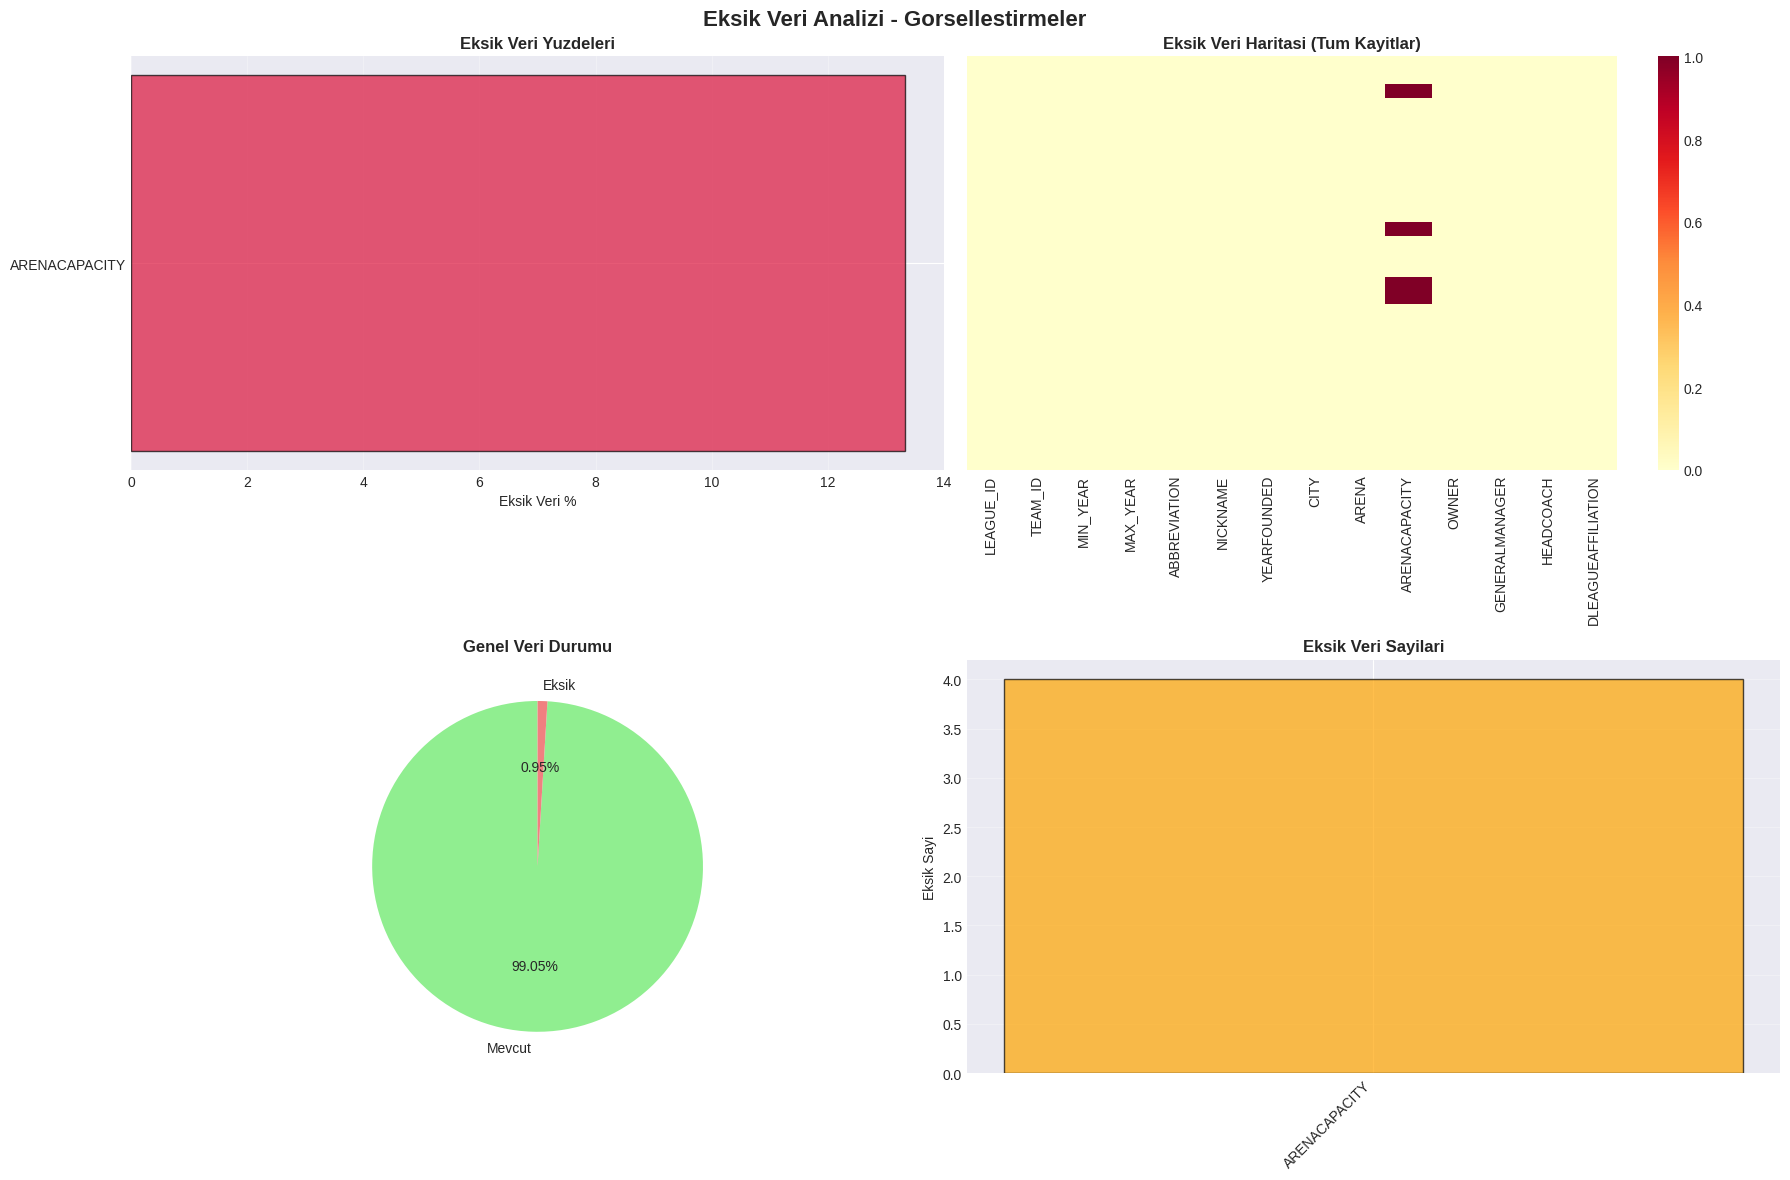

In [12]:
# Eksik veri görselleştirmesi
if len(missing_cols) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle('Eksik Veri Analizi - Gorsellestirmeler',
                fontsize=16, fontweight='bold')

    # 1. Bar plot
    axes[0, 0].barh(range(len(missing_cols)), missing_cols['Eksik_Yuzde'],
                   color='crimson', edgecolor='black', alpha=0.7)
    axes[0, 0].set_yticks(range(len(missing_cols)))
    axes[0, 0].set_yticklabels(missing_cols['Sutun'])
    axes[0, 0].set_xlabel('Eksik Veri %')
    axes[0, 0].set_title('Eksik Veri Yuzdeleri', fontweight='bold')
    axes[0, 0].grid(axis='x', alpha=0.3)
    axes[0, 0].invert_yaxis()

    # 2. Heatmap
    sns.heatmap(df.isnull(), cbar=True, yticklabels=False,
               cmap='YlOrRd', ax=axes[0, 1])
    axes[0, 1].set_title(f'Eksik Veri Haritasi (Tum Kayitlar)', fontweight='bold')

    # 3. Pie chart
    total_cells = len(df) * len(df.columns)
    missing_cells = missing_cols['Eksik_Sayi'].sum()
    present_cells = total_cells - missing_cells

    axes[1, 0].pie([present_cells, missing_cells],
                  labels=['Mevcut', 'Eksik'],
                  autopct='%1.2f%%', startangle=90,
                  colors=['lightgreen', 'lightcoral'])
    axes[1, 0].set_title('Genel Veri Durumu', fontweight='bold')

    # 4. Count plot
    axes[1, 1].bar(range(len(missing_cols)), missing_cols['Eksik_Sayi'],
                  color='orange', edgecolor='black', alpha=0.7)
    axes[1, 1].set_xticks(range(len(missing_cols)))
    axes[1, 1].set_xticklabels(missing_cols['Sutun'], rotation=45, ha='right')
    axes[1, 1].set_ylabel('Eksik Sayi')
    axes[1, 1].set_title('Eksik Veri Sayilari', fontweight='bold')
    axes[1, 1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("Eksik veri olmadigi icin gorsellestirme yapilmadi.")

## 🏆 Takım İsim ve Kısaltma Analizleri

In [13]:
# Takım isim analizi
print("="*70)
print("TAKIM ISIM VE KISALTMA ANALIZI")
print("="*70)

if 'NICKNAME' in df.columns:
    print(f"\nNICKNAME (Takim Ismi):")
    print(f"  Benzersiz: {df['NICKNAME'].nunique()}")
    print(f"  Toplam Kayit: {len(df)}")

    # İsim uzunlukları
    df['nickname_length'] = df['NICKNAME'].str.len()
    print(f"\nNickname Uzunlugu:")
    print(f"  Ortalama: {df['nickname_length'].mean():.2f} karakter")
    print(f"  Medyan: {df['nickname_length'].median():.0f} karakter")
    print(f"  Min: {df['nickname_length'].min():.0f} ({df.loc[df['nickname_length'].idxmin(), 'NICKNAME']})")
    print(f"  Max: {df['nickname_length'].max():.0f} ({df.loc[df['nickname_length'].idxmax(), 'NICKNAME']})")

    print(f"\nTUM TAKIMLAR (NICKNAME):")
    for idx, name in enumerate(sorted(df['NICKNAME'].unique()), 1):
        print(f"  {idx:2d}. {name}")

if 'ABBREVIATION' in df.columns:
    print(f"\nABBREVIATION (Kisaltma):")
    print(f"  Benzersiz: {df['ABBREVIATION'].nunique()}")

    # Kısaltma uzunlukları
    df['abbr_length'] = df['ABBREVIATION'].str.len()
    print(f"\nKisaltma Uzunlugu:")
    print(f"  Ortalama: {df['abbr_length'].mean():.2f} karakter")
    print(f"  Medyan: {df['abbr_length'].median():.0f} karakter")
    print(f"  Min: {df['abbr_length'].min():.0f}")
    print(f"  Max: {df['abbr_length'].max():.0f}")

    # Kısaltma dağılımı
    abbr_len_dist = df['abbr_length'].value_counts().sort_index()
    print(f"\nKisaltma Uzunlugu Dagilimi:")
    for length, count in abbr_len_dist.items():
        print(f"  {length:.0f} karakter: {count} takim")

TAKIM ISIM VE KISALTMA ANALIZI

NICKNAME (Takim Ismi):
  Benzersiz: 30
  Toplam Kayit: 30

Nickname Uzunlugu:
  Ortalama: 6.70 karakter
  Medyan: 7 karakter
  Min: 4 (Heat)
  Max: 13 (Trail Blazers)

TUM TAKIMLAR (NICKNAME):
   1. 76ers
   2. Bucks
   3. Bulls
   4. Cavaliers
   5. Celtics
   6. Clippers
   7. Grizzlies
   8. Hawks
   9. Heat
  10. Hornets
  11. Jazz
  12. Kings
  13. Knicks
  14. Lakers
  15. Magic
  16. Mavericks
  17. Nets
  18. Nuggets
  19. Pacers
  20. Pelicans
  21. Pistons
  22. Raptors
  23. Rockets
  24. Spurs
  25. Suns
  26. Thunder
  27. Timberwolves
  28. Trail Blazers
  29. Warriors
  30. Wizards

ABBREVIATION (Kisaltma):
  Benzersiz: 30

Kisaltma Uzunlugu:
  Ortalama: 3.00 karakter
  Medyan: 3 karakter
  Min: 3
  Max: 3

Kisaltma Uzunlugu Dagilimi:
  3 karakter: 30 takim


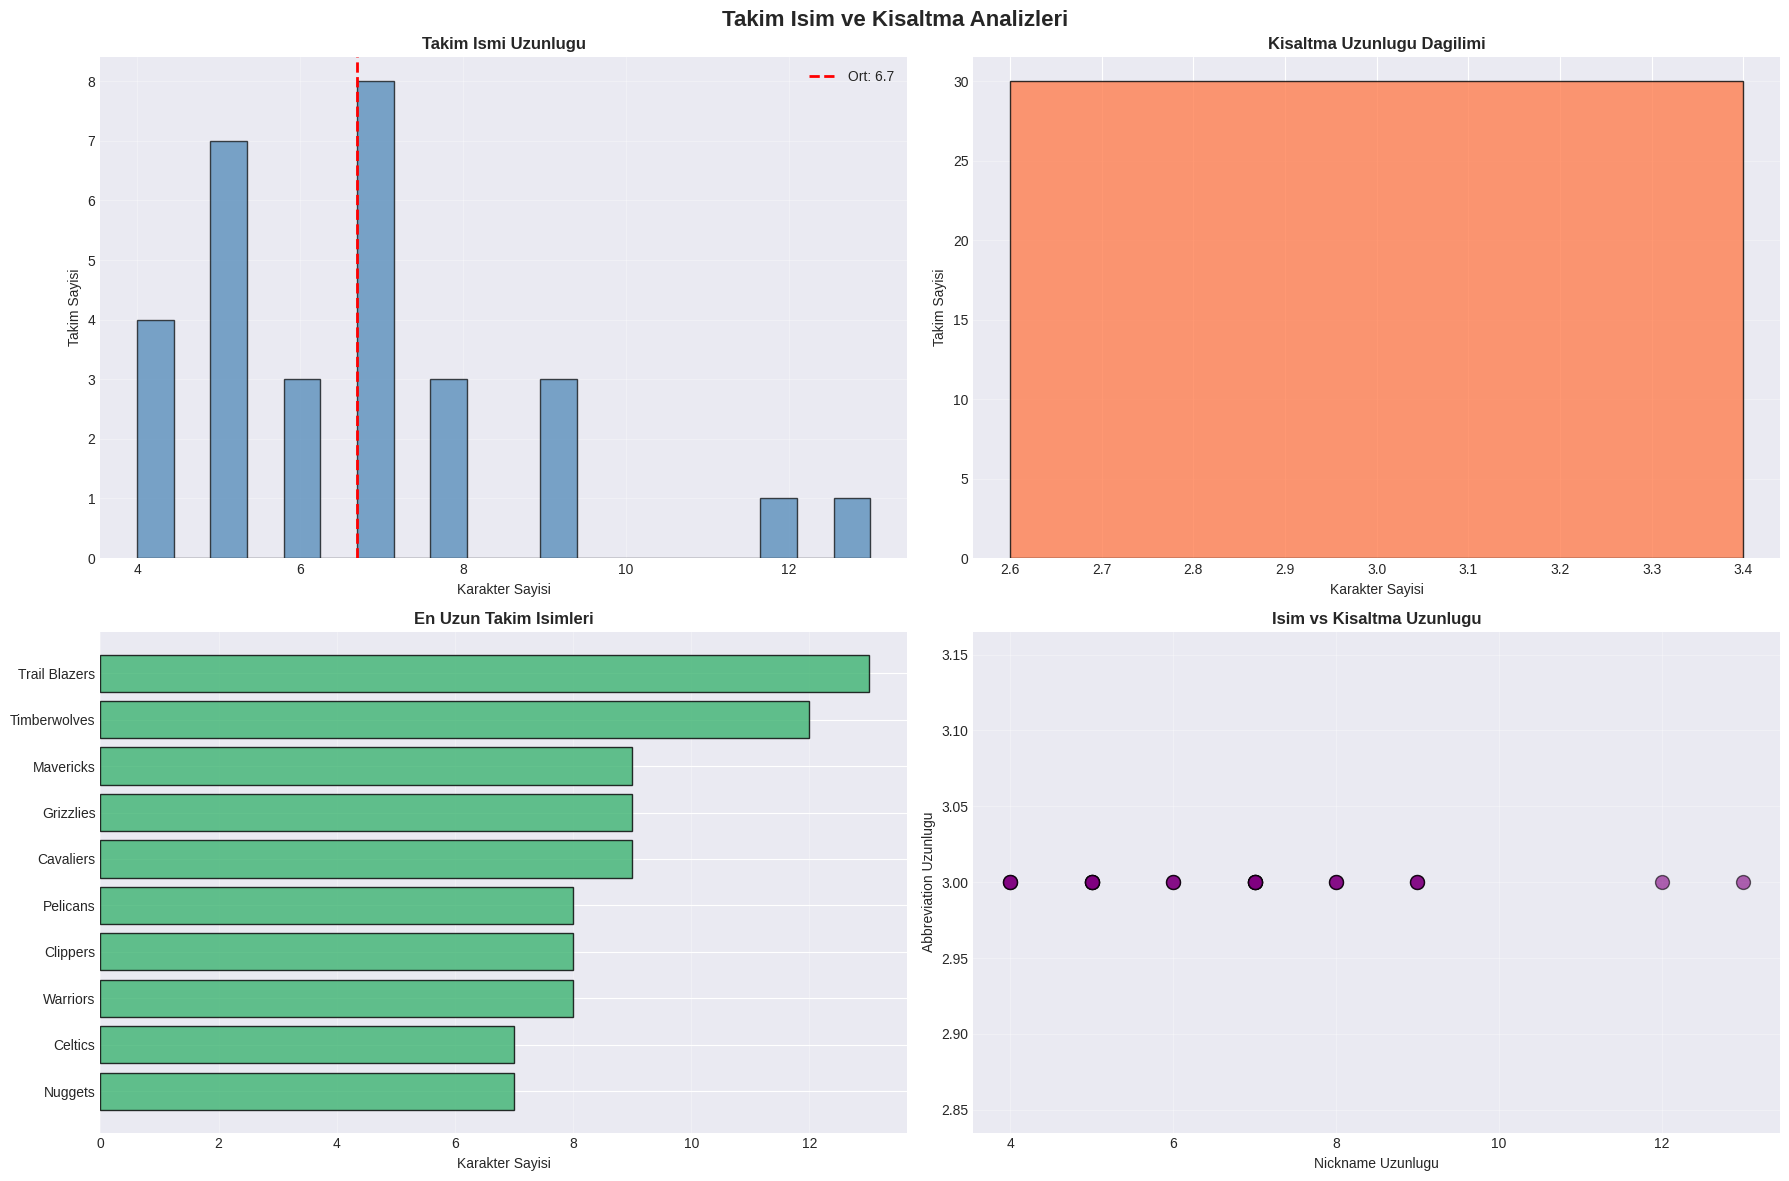

In [14]:
# İsim ve kısaltma görselleştirmeleri
if 'nickname_length' in df.columns and 'abbr_length' in df.columns:
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle('Takim Isim ve Kisaltma Analizleri',
                fontsize=16, fontweight='bold')

    # 1. Nickname uzunluğu
    axes[0, 0].hist(df['nickname_length'], bins=20, color='steelblue',
                   edgecolor='black', alpha=0.7)
    axes[0, 0].axvline(df['nickname_length'].mean(), color='red', linestyle='--',
                      linewidth=2, label=f"Ort: {df['nickname_length'].mean():.1f}")
    axes[0, 0].set_title('Takim Ismi Uzunlugu', fontweight='bold')
    axes[0, 0].set_xlabel('Karakter Sayisi')
    axes[0, 0].set_ylabel('Takim Sayisi')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)

    # 2. Abbreviation uzunluğu
    abbr_counts = df['abbr_length'].value_counts().sort_index()
    axes[0, 1].bar(abbr_counts.index, abbr_counts.values,
                  color='coral', edgecolor='black', alpha=0.8)
    axes[0, 1].set_title('Kisaltma Uzunlugu Dagilimi', fontweight='bold')
    axes[0, 1].set_xlabel('Karakter Sayisi')
    axes[0, 1].set_ylabel('Takim Sayisi')
    axes[0, 1].grid(axis='y', alpha=0.3)

    # 3. En uzun nicknameler
    if 'NICKNAME' in df.columns:
        top_10_long = df.nlargest(10, 'nickname_length')[['NICKNAME', 'nickname_length']]
        axes[1, 0].barh(range(10), top_10_long['nickname_length'].values,
                       color='mediumseagreen', edgecolor='black', alpha=0.8)
        axes[1, 0].set_yticks(range(10))
        axes[1, 0].set_yticklabels(top_10_long['NICKNAME'].values)
        axes[1, 0].set_xlabel('Karakter Sayisi')
        axes[1, 0].set_title('En Uzun Takim Isimleri', fontweight='bold')
        axes[1, 0].grid(axis='x', alpha=0.3)
        axes[1, 0].invert_yaxis()

    # 4. Nickname vs Abbreviation scatter
    axes[1, 1].scatter(df['nickname_length'], df['abbr_length'],
                      alpha=0.6, s=100, color='purple', edgecolor='black')
    axes[1, 1].set_title('Isim vs Kisaltma Uzunlugu', fontweight='bold')
    axes[1, 1].set_xlabel('Nickname Uzunlugu')
    axes[1, 1].set_ylabel('Abbreviation Uzunlugu')
    axes[1, 1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

## 🌆 Şehir Dağılımları ve Multi-Team Cities

In [15]:
# Şehir analizi
if 'CITY' in df.columns:
    print("="*70)
    print("SEHIR DAGILIM ANALIZI")
    print("="*70)

    city_counts = df['CITY'].value_counts()

    print(f"\nGenel Bilgiler:")
    print(f"  Benzersiz Sehir: {df['CITY'].nunique()}")
    print(f"  Toplam Takim: {len(df)}")
    print(f"  Ort. Takim/Sehir: {len(df) / df['CITY'].nunique():.2f}")

    # Çok takımlı şehirler
    multi_team_cities = city_counts[city_counts > 1]

    print(f"\nCOK TAKIMLI SEHIRLER:")
    if len(multi_team_cities) > 0:
        print(f"  Toplam: {len(multi_team_cities)} sehir")
        print("="*70)
        for city, count in multi_team_cities.sort_values(ascending=False).items():
            teams_in_city = df[df['CITY'] == city]['NICKNAME'].tolist()
            print(f"\n  {city}: {count} takim")
            for team in teams_in_city:
                print(f"     - {team}")
    else:
        print("  Yok (her sehirde tek takim)")

    # Tek takımlı şehirler
    single_team_cities = city_counts[city_counts == 1]
    print(f"\nTEK TAKIMLI SEHIRLER:")
    print(f"  Toplam: {len(single_team_cities)} sehir")

    # Tüm şehirler alfabetik
    print(f"\nTUM SEHIRLER (Alfabetik):")
    print("="*70)
    for idx, city in enumerate(sorted(df['CITY'].unique()), 1):
        count = city_counts[city]
        print(f"  {idx:2d}. {city:25} ({count} takim)")

SEHIR DAGILIM ANALIZI

Genel Bilgiler:
  Benzersiz Sehir: 29
  Toplam Takim: 30
  Ort. Takim/Sehir: 1.03

COK TAKIMLI SEHIRLER:
  Toplam: 1 sehir

  Los Angeles: 2 takim
     - Clippers
     - Lakers

TEK TAKIMLI SEHIRLER:
  Toplam: 28 sehir

TUM SEHIRLER (Alfabetik):
   1. Atlanta                   (1 takim)
   2. Boston                    (1 takim)
   3. Brooklyn                  (1 takim)
   4. Charlotte                 (1 takim)
   5. Chicago                   (1 takim)
   6. Cleveland                 (1 takim)
   7. Dallas                    (1 takim)
   8. Denver                    (1 takim)
   9. Detroit                   (1 takim)
  10. Golden State              (1 takim)
  11. Houston                   (1 takim)
  12. Indiana                   (1 takim)
  13. Los Angeles               (2 takim)
  14. Memphis                   (1 takim)
  15. Miami                     (1 takim)
  16. Milwaukee                 (1 takim)
  17. Minnesota                 (1 takim)
  18. New Orleans

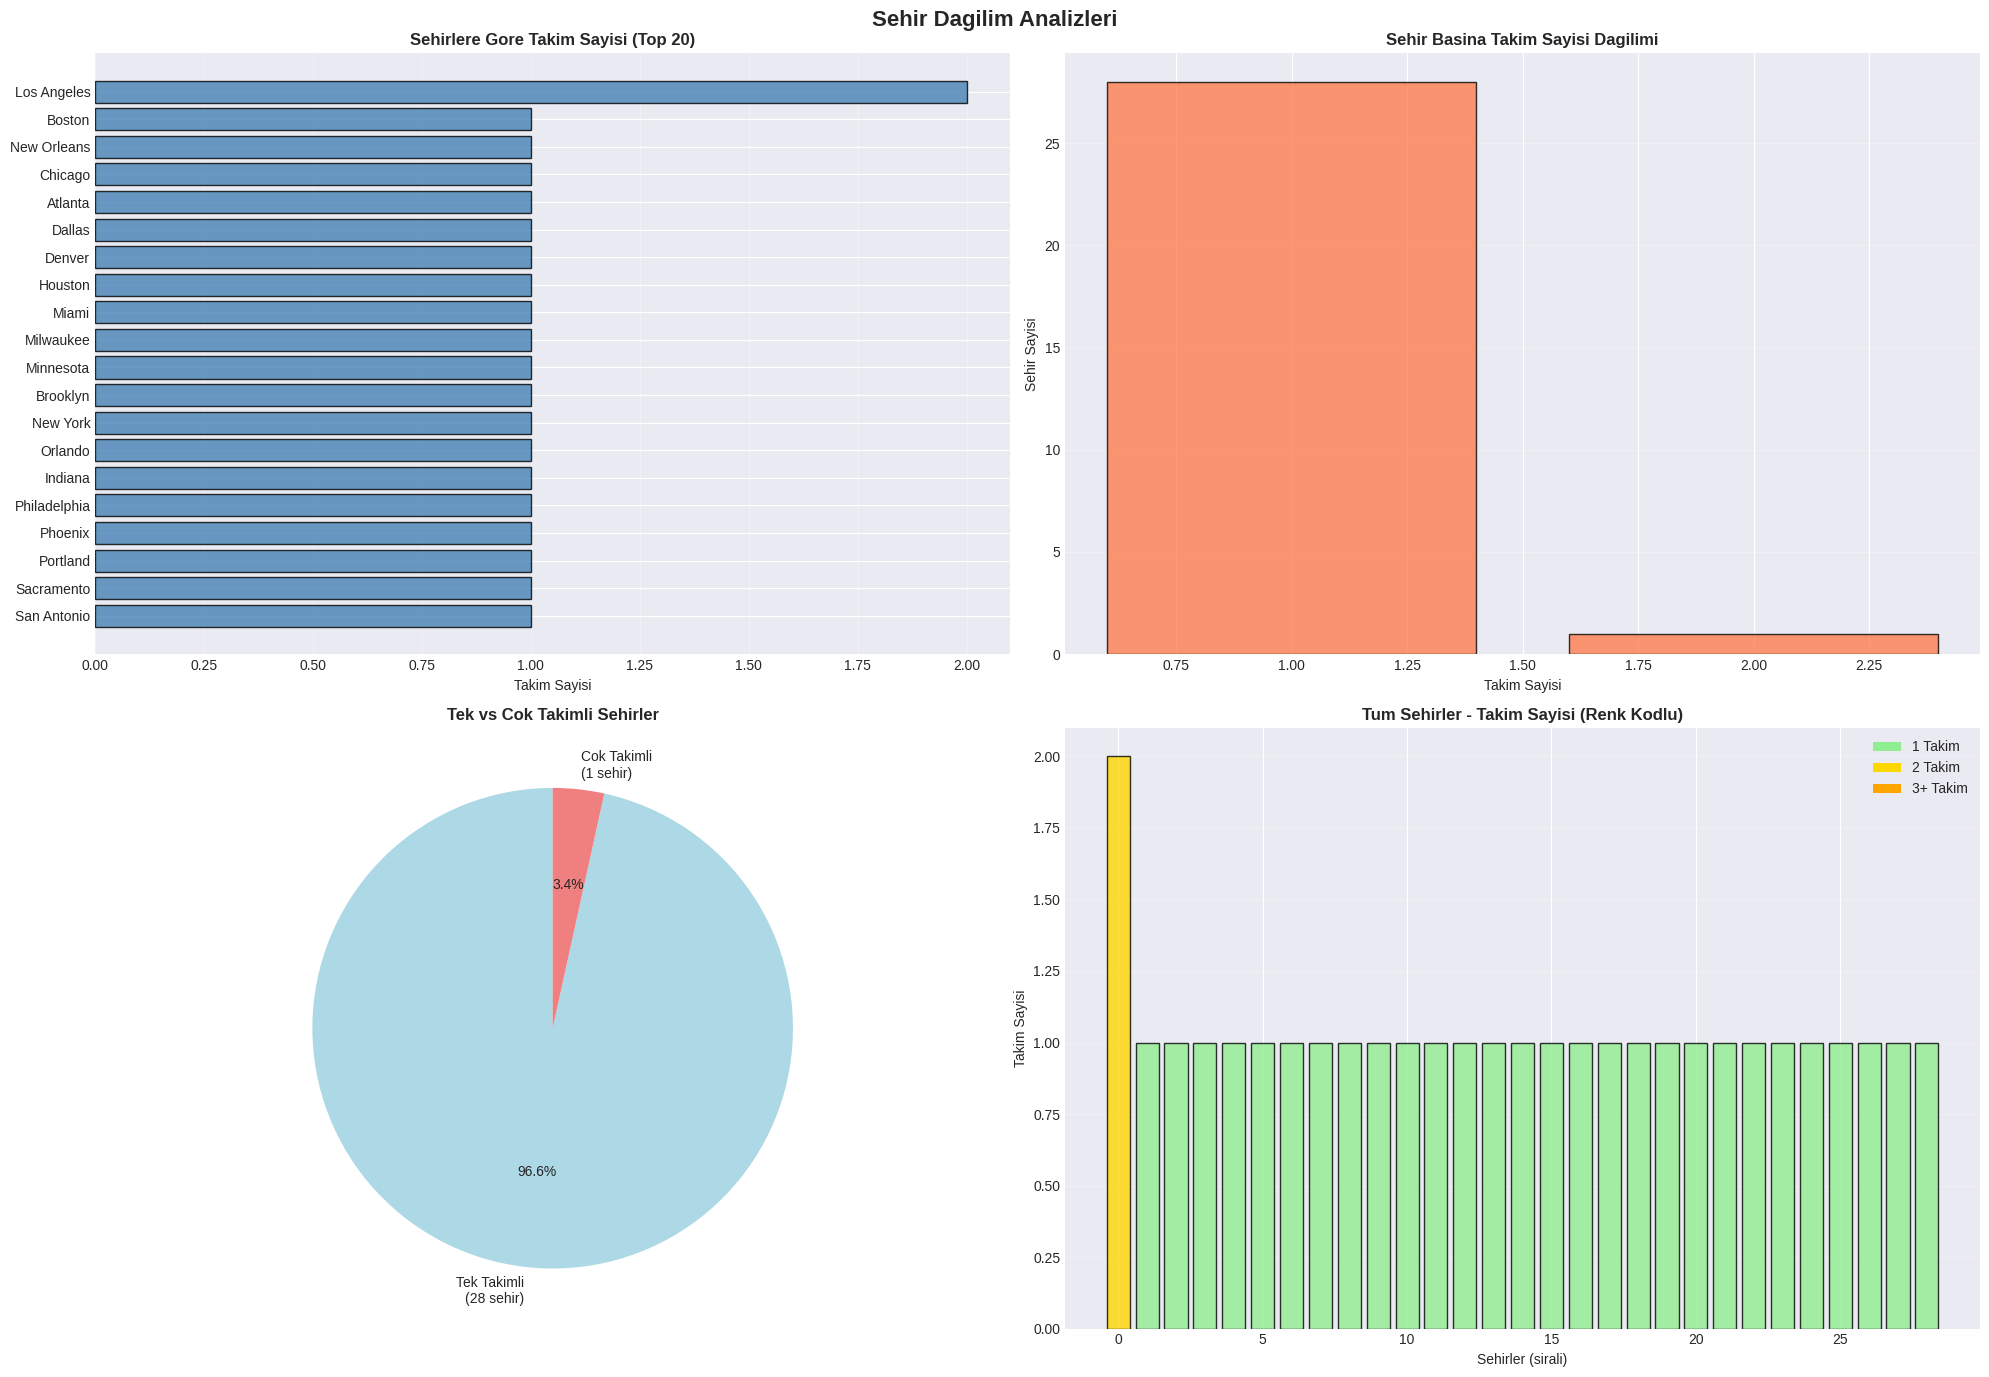

In [16]:
# Şehir görselleştirmeleri
if 'CITY' in df.columns:
    fig, axes = plt.subplots(2, 2, figsize=(20, 14))
    fig.suptitle('Sehir Dagilim Analizleri',
                fontsize=16, fontweight='bold')

    # 1. Şehirlere göre takım sayısı (top 20)
    top_cities = city_counts.head(20)
    axes[0, 0].barh(range(len(top_cities)), top_cities.values,
                   color='steelblue', edgecolor='black', alpha=0.8)
    axes[0, 0].set_yticks(range(len(top_cities)))
    axes[0, 0].set_yticklabels(top_cities.index)
    axes[0, 0].set_xlabel('Takim Sayisi')
    axes[0, 0].set_title('Sehirlere Gore Takim Sayisi (Top 20)', fontweight='bold')
    axes[0, 0].grid(axis='x', alpha=0.3)
    axes[0, 0].invert_yaxis()

    # 2. Takım/şehir dağılımı
    team_per_city_dist = city_counts.value_counts().sort_index()
    axes[0, 1].bar(team_per_city_dist.index, team_per_city_dist.values,
                  color='coral', edgecolor='black', alpha=0.8)
    axes[0, 1].set_title('Sehir Basina Takim Sayisi Dagilimi', fontweight='bold')
    axes[0, 1].set_xlabel('Takim Sayisi')
    axes[0, 1].set_ylabel('Sehir Sayisi')
    axes[0, 1].grid(axis='y', alpha=0.3)

    # 3. Tek vs Çok takımlı pie chart
    single_count = len(single_team_cities)
    multi_count = len(multi_team_cities)
    axes[1, 0].pie([single_count, multi_count],
                  labels=[f'Tek Takimli\n({single_count} sehir)',
                         f'Cok Takimli\n({multi_count} sehir)'],
                  autopct='%1.1f%%', startangle=90,
                  colors=['lightblue', 'lightcoral'])
    axes[1, 0].set_title('Tek vs Cok Takimli Sehirler', fontweight='bold')

    # 4. Takım sayısına göre şehir dağılımı
    colors_map = {1: 'lightgreen', 2: 'gold', 3: 'orange'}
    colors_list = [colors_map.get(count, 'red') for count in city_counts.values]

    axes[1, 1].bar(range(len(city_counts)), city_counts.values,
                  color=colors_list, edgecolor='black', alpha=0.8)
    axes[1, 1].set_title('Tum Sehirler - Takim Sayisi (Renk Kodlu)', fontweight='bold')
    axes[1, 1].set_xlabel('Sehirler (sirali)')
    axes[1, 1].set_ylabel('Takim Sayisi')
    axes[1, 1].grid(axis='y', alpha=0.3)

    # Legend ekle
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='lightgreen', label='1 Takim'),
                      Patch(facecolor='gold', label='2 Takim'),
                      Patch(facecolor='orange', label='3+ Takim')]
    axes[1, 1].legend(handles=legend_elements)

    plt.tight_layout()
    plt.show()

## 📅 Kuruluş Yılı Deep Dive

In [17]:
# Kuruluş yılı analizi
if 'YEARFOUNDED' in df.columns:
    print("="*70)
    print("KURULUS YILI - DETAYLI ANALIZ")
    print("="*70)

    year_data = df['YEARFOUNDED'].dropna()
    current_year = 2024

    print(f"\nGenel Istatistikler:")
    print(f"  Ilk Kurulus: {year_data.min():.0f}")
    print(f"  Son Kurulus: {year_data.max():.0f}")
    print(f"  Ortalama: {year_data.mean():.2f}")
    print(f"  Medyan: {year_data.median():.0f}")
    print(f"  Std Sapma: {year_data.std():.2f}")
    print(f"  Kapsam: {year_data.max() - year_data.min():.0f} yil")

    # Takım yaşları
    df['Team_Age'] = current_year - df['YEARFOUNDED']

    print(f"\nTAKIM YASLARI (2024 itibariyla):")
    print(f"  Ortalama Yas: {df['Team_Age'].mean():.2f} yil")
    print(f"  Medyan Yas: {df['Team_Age'].median():.0f} yil")
    print(f"  En Genc: {df['Team_Age'].min():.0f} yil")
    print(f"  En Yasli: {df['Team_Age'].max():.0f} yil")

    # En eski takımlar
    print(f"\nEN ESKI TAKIMLAR (Top 10):")
    print("="*70)
    oldest = df.nsmallest(10, 'YEARFOUNDED')[['NICKNAME', 'CITY', 'YEARFOUNDED', 'Team_Age']]
    for idx, row in oldest.iterrows():
        print(f"  {row['CITY']:20} {row['NICKNAME']:20} - {row['YEARFOUNDED']:.0f} ({row['Team_Age']:.0f} yasinda)")

    # En yeni takımlar
    print(f"\nEN YENI TAKIMLAR (Top 10):")
    print("="*70)
    newest = df.nlargest(10, 'YEARFOUNDED')[['NICKNAME', 'CITY', 'YEARFOUNDED', 'Team_Age']]
    for idx, row in newest.iterrows():
        print(f"  {row['CITY']:20} {row['NICKNAME']:20} - {row['YEARFOUNDED']:.0f} ({row['Team_Age']:.0f} yasinda)")

    # Dekatlara göre dağılım
    df['Founded_Decade'] = (df['YEARFOUNDED'] // 10 * 10).astype('Int64')
    decade_counts = df['Founded_Decade'].value_counts().sort_index()

    print(f"\nDEKATLARA GORE KURULUS DAGILIMI:")
    for decade, count in decade_counts.items():
        print(f"  {decade}ler: {count} takim")

KURULUS YILI - DETAYLI ANALIZ

Genel Istatistikler:
  Ilk Kurulus: 1946
  Son Kurulus: 2002
  Ortalama: 1969.70
  Medyan: 1970
  Std Sapma: 16.70
  Kapsam: 56 yil

TAKIM YASLARI (2024 itibariyla):
  Ortalama Yas: 54.30 yil
  Medyan Yas: 54 yil
  En Genc: 22 yil
  En Yasli: 78 yil

EN ESKI TAKIMLAR (Top 10):
  Boston               Celtics              - 1946 (78 yasinda)
  New York             Knicks               - 1946 (78 yasinda)
  Golden State         Warriors             - 1946 (78 yasinda)
  Los Angeles          Lakers               - 1948 (76 yasinda)
  Sacramento           Kings                - 1948 (76 yasinda)
  Detroit              Pistons              - 1948 (76 yasinda)
  Atlanta              Hawks                - 1949 (75 yasinda)
  Philadelphia         76ers                - 1949 (75 yasinda)
  Washington           Wizards              - 1961 (63 yasinda)
  Chicago              Bulls                - 1966 (58 yasinda)

EN YENI TAKIMLAR (Top 10):
  New Orleans          

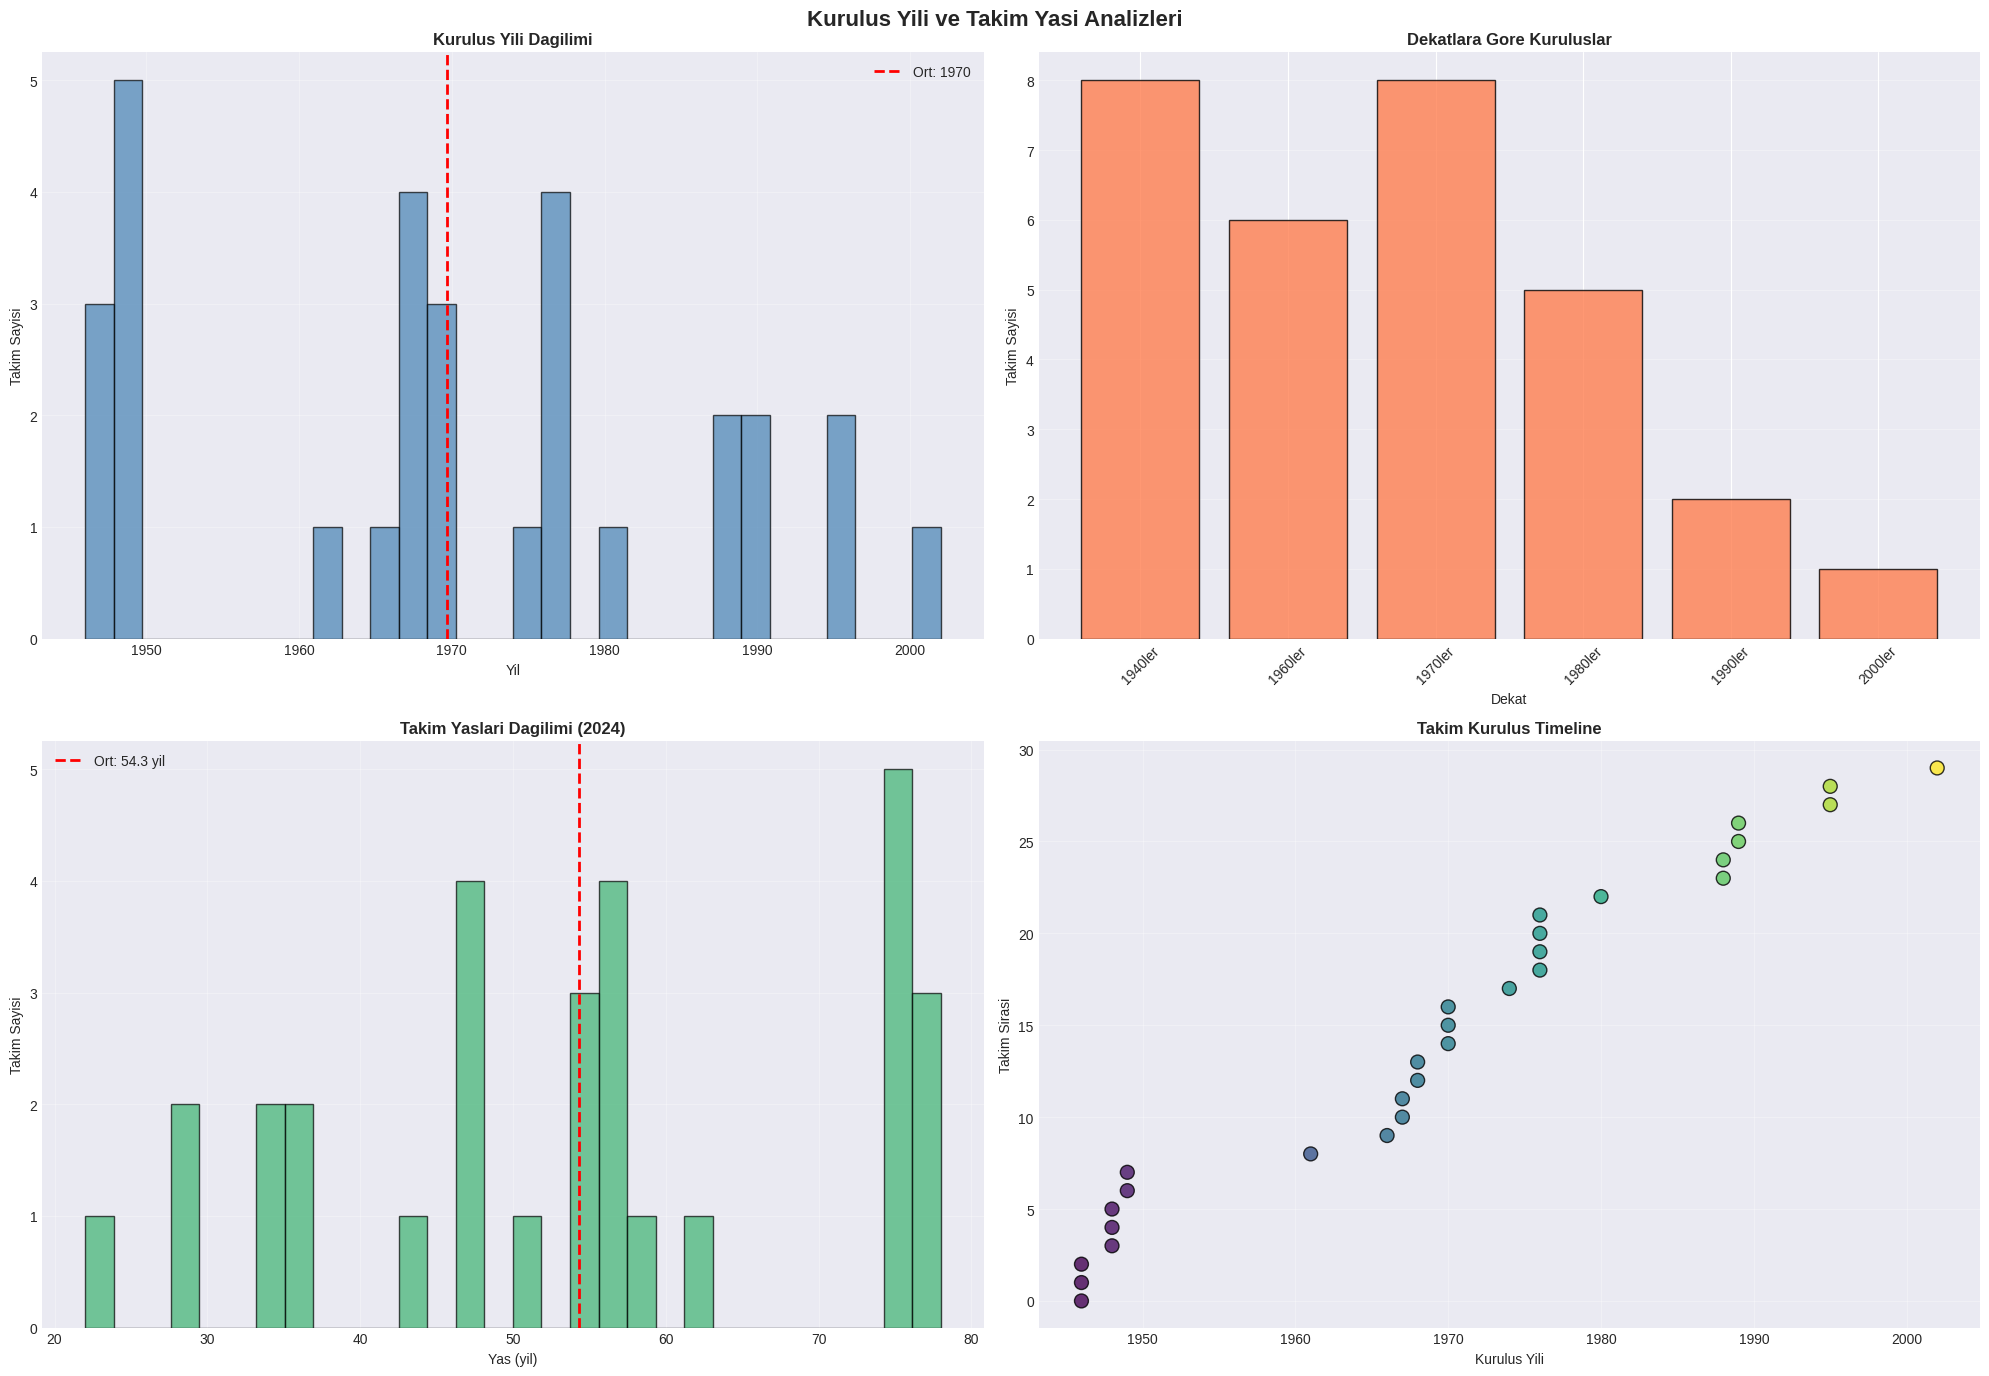

In [18]:
# Kuruluş yılı görselleştirmeleri
if 'YEARFOUNDED' in df.columns and 'Team_Age' in df.columns:
    fig, axes = plt.subplots(2, 2, figsize=(20, 14))
    fig.suptitle('Kurulus Yili ve Takim Yasi Analizleri',
                fontsize=16, fontweight='bold')

    # 1. Kuruluş yılı dağılımı
    axes[0, 0].hist(df['YEARFOUNDED'].dropna(), bins=30, color='steelblue',
                   edgecolor='black', alpha=0.7)
    axes[0, 0].axvline(df['YEARFOUNDED'].mean(), color='red', linestyle='--',
                      linewidth=2, label=f"Ort: {df['YEARFOUNDED'].mean():.0f}")
    axes[0, 0].set_title('Kurulus Yili Dagilimi', fontweight='bold')
    axes[0, 0].set_xlabel('Yil')
    axes[0, 0].set_ylabel('Takim Sayisi')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)

    # 2. Dekat bazında
    if 'Founded_Decade' in df.columns:
        decade_counts = df['Founded_Decade'].value_counts().sort_index()
        decade_labels = [str(int(d)) + 'ler' for d in decade_counts.index]
        axes[0, 1].bar(decade_labels, decade_counts.values,
                      color='coral', edgecolor='black', alpha=0.8)
        axes[0, 1].set_title('Dekatlara Gore Kuruluslar', fontweight='bold')
        axes[0, 1].set_xlabel('Dekat')
        axes[0, 1].set_ylabel('Takim Sayisi')
        axes[0, 1].tick_params(axis='x', rotation=45)
        axes[0, 1].grid(axis='y', alpha=0.3)

    # 3. Takım yaşları dağılımı
    axes[1, 0].hist(df['Team_Age'].dropna(), bins=30, color='mediumseagreen',
                   edgecolor='black', alpha=0.7)
    axes[1, 0].axvline(df['Team_Age'].mean(), color='red', linestyle='--',
                      linewidth=2, label=f"Ort: {df['Team_Age'].mean():.1f} yil")
    axes[1, 0].set_title('Takim Yaslari Dagilimi (2024)', fontweight='bold')
    axes[1, 0].set_xlabel('Yas (yil)')
    axes[1, 0].set_ylabel('Takim Sayisi')
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)

    # 4. Timeline
    df_sorted = df.sort_values('YEARFOUNDED')
    axes[1, 1].scatter(df_sorted['YEARFOUNDED'], range(len(df_sorted)),
                      c=df_sorted['YEARFOUNDED'], cmap='viridis',
                      s=100, edgecolor='black', alpha=0.8)
    axes[1, 1].set_title('Takim Kurulus Timeline', fontweight='bold')
    axes[1, 1].set_xlabel('Kurulus Yili')
    axes[1, 1].set_ylabel('Takim Sirasi')
    axes[1, 1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

## 📝 TEAMS.CSV - Kapsamlı Özet Raporu

In [19]:
# Final kapsamlı özet
print("\n" + "="*80)
print("TEAMS.CSV - KAPSAMLI OZET RAPOR")
print("="*80)

print(f"\nVERI SETI:")
print(f"  Toplam Takim: {len(df):,}")
print(f"  Sutun Sayisi: {len(df.columns)}")
print(f"  Bellek: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

if 'NICKNAME' in df.columns:
    print(f"\nTAKIM BILGILERI:")
    print(f"  Benzersiz Takim: {df['NICKNAME'].nunique()}")
    if 'nickname_length' in df.columns:
        print(f"  Ort. Isim Uzunlugu: {df['nickname_length'].mean():.1f} karakter")

if 'CITY' in df.columns:
    print(f"\nSEHIR BILGILERI:")
    print(f"  Benzersiz Sehir: {df['CITY'].nunique()}")
    if 'city_counts' in locals():
        multi_cities = len(city_counts[city_counts > 1])
        print(f"  Cok Takimli Sehir: {multi_cities}")
        print(f"  Tek Takimli Sehir: {df['CITY'].nunique() - multi_cities}")

if 'YEARFOUNDED' in df.columns:
    print(f"\nKURULUS BILGILERI:")
    print(f"  Ilk Kurulus: {df['YEARFOUNDED'].min():.0f}")
    print(f"  Son Kurulus: {df['YEARFOUNDED'].max():.0f}")
    print(f"  Ort. Kurulus Yili: {df['YEARFOUNDED'].mean():.0f}")
    if 'Team_Age' in df.columns:
        print(f"  Ort. Takim Yasi: {df['Team_Age'].mean():.1f} yil")
        print(f"  En Genc: {df['Team_Age'].min():.0f} yil")
        print(f"  En Yasli: {df['Team_Age'].max():.0f} yil")

print(f"\nVERI KALITESI:")
total_cells = len(df) * len(df.columns)
missing_cells = df.isnull().sum().sum()
print(f"  Toplam Hucre: {total_cells:,}")
print(f"  Eksik Hucre: {missing_cells:,}")
print(f"  Eksiklik Orani: {(missing_cells/total_cells*100):.2f}%")

print("\n" + "="*80)
print("TEAMS.CSV KAPSAMLI ANALIZI TAMAMLANDI!")
print("="*80)
print("\nSonraki Adimlar:")
print("  - Takim gecmisi timeline'lari olusturun")
print("  - Bolgesel rekabet analizleri yapin")
print("  - Franchise deger tahminleri gelistirin")
print("  - Takim basari vs kurulus yili korelasyonu")
print("  - Multi-team cities detayli analizi")
print("\n" + "="*80)


TEAMS.CSV - KAPSAMLI OZET RAPOR

VERI SETI:
  Toplam Takim: 30
  Sutun Sayisi: 18
  Bellek: 0.02 MB

TAKIM BILGILERI:
  Benzersiz Takim: 30
  Ort. Isim Uzunlugu: 6.7 karakter

SEHIR BILGILERI:
  Benzersiz Sehir: 29
  Cok Takimli Sehir: 1
  Tek Takimli Sehir: 28

KURULUS BILGILERI:
  Ilk Kurulus: 1946
  Son Kurulus: 2002
  Ort. Kurulus Yili: 1970
  Ort. Takim Yasi: 54.3 yil
  En Genc: 22 yil
  En Yasli: 78 yil

VERI KALITESI:
  Toplam Hucre: 540
  Eksik Hucre: 4
  Eksiklik Orani: 0.74%

TEAMS.CSV KAPSAMLI ANALIZI TAMAMLANDI!

Sonraki Adimlar:
  - Takim gecmisi timeline'lari olusturun
  - Bolgesel rekabet analizleri yapin
  - Franchise deger tahminleri gelistirin
  - Takim basari vs kurulus yili korelasyonu
  - Multi-team cities detayli analizi

